In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import emcee

# basics of matrices: Eigenvalue and Eigenvectors

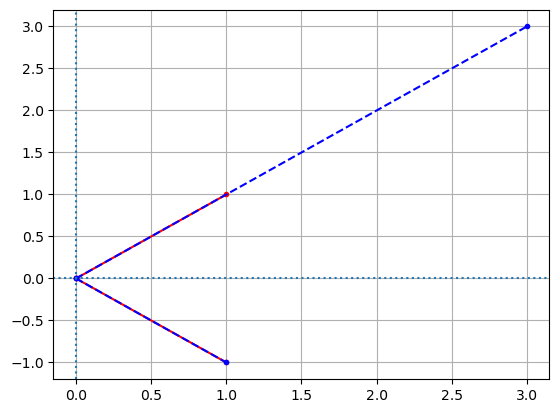

In [9]:
# plot for rotations
theta = np.pi*90/180 # angles
A = np.array([[2, 1], [1, 2]])
v1 = np.array([[1], [1]])
v2 = np.array([[1], [-1]])
plt.plot([0, v1[0, 0]], [0, v1[1, 0]], marker = '.', color = 'red')
plt.plot([0, v2[0, 0]], [0, v2[1, 0]], marker = '.', color = 'red')
plt.plot([0, (A@v1)[0, 0]], [0, (A@v1)[1, 0]], marker = '.', color = 'b', linestyle = '--')
plt.plot([0, (A@v2)[0, 0]], [0, (A@v2)[1, 0]], marker = '.', color = 'b', linestyle = '--')
plt.axhline(0, linestyle = ':')
plt.axvline(0, linestyle = ':')
plt.grid()
# Eigenvector give you symmetry, direction does not change during linear transformation.
# By lowering the dimention of matrix ==> (rank < n).

In [70]:
A = np.array([[2, 1],
              [1, 2]])
values, vectors = np.linalg.eig(A@A@A)
print (values)
print(vectors)

[27.  1.]
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


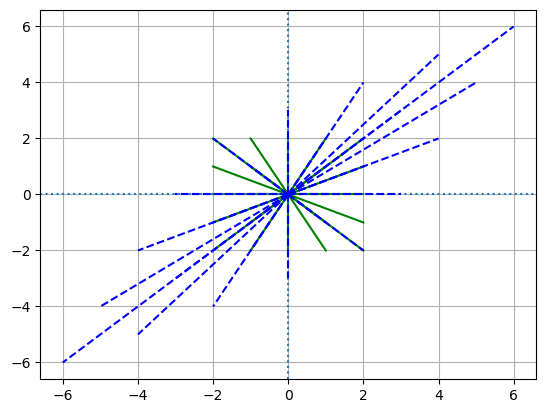

In [37]:
A = np.array([[2, 1],
              [1, 2]])

x = np.arange(-2, 2.1, 1)
y = np.arange(-2, 2.1, 1)

for i in range(len(x)):
    for j in range(len(y)):
        v = np.array([[x[i]],
                      [y[j]]])
        plt.plot([0, v[0, 0]], [0, v[1, 0]], marker = '', color = 'green', linestyle = '-')
        plt.plot([0, (A@v)[0, 0]], [0, (A@v)[1, 0]], marker = '', color = 'b', linestyle = '--', zorder = 300)

plt.axhline(0, linestyle = ':')
plt.axvline(0, linestyle = ':')
#plt.axis('equal')
plt.grid()

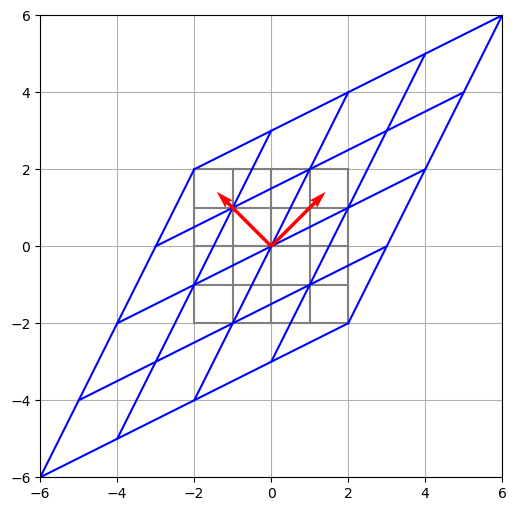

In [49]:
n = 50
A = np.array([[2,1],
              [1,2]])

x = np.linspace(-2,2,5)

plt.figure(figsize = (6,6), dpi=100)

# original grid
for i in x:
    y = np.linspace(-2,2,n)
    pts = np.vstack([np.full_like(y,i),y])
    plt.plot(pts[0], pts[1], color = 'grey')

for j in x:
    x2 = np.linspace(-2,2,n)
    pts = np.vstack([x2,np.full_like(x2,j)])
    plt.plot(pts[0], pts[1], color = 'grey')

# Transformed grid
for i in x:
    y = np.linspace(-2,2,n)
    pts = np.vstack([np.full_like(y,i),y])
    new = (A@pts)
    plt.plot(new[0], new[1], color = 'blue')

for j in x:
    x2 = np.linspace(-2,2,n)
    pts = np.vstack([x2,np.full_like(x2,j)])
    new = (A@pts)
    plt.plot(new[0], new[1], color = 'blue')

# eigenvectors 
values, vectors = np.linalg.eig(A)
v1 = vectors[:,0]
v2 = vectors[:,1]

plt.quiver(0,0,v1[0],v1[1], color = 'red', scale = 0.5, scale_units = 'xy', zorder = 1000)
plt.quiver(0,0,v2[0],v2[1], color = 'red', scale = 0.5, scale_units = 'xy', zorder = 1000)

plt.xlim(-6,6)
plt.ylim(-6,6)
plt.grid()
plt.gca().set_aspect('equal')

plt.show()

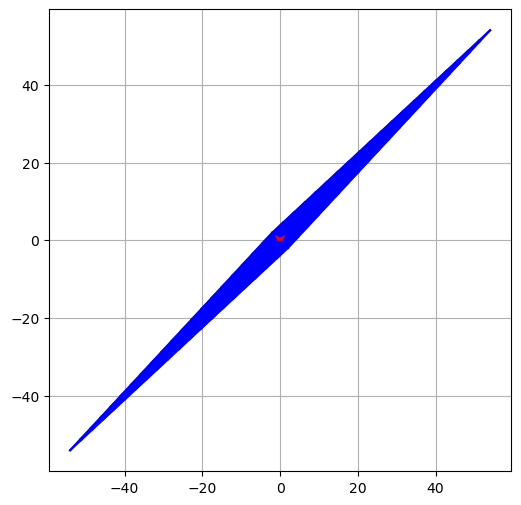

In [69]:
N = 3
n = 50
A = np.array([[2,1],
              [1,2]])

x = np.linspace(-2,2,21)

plt.figure(figsize = (6,6))

# original grid
for i in x:
    y = np.linspace(-2,2,n)
    pts = np.vstack([np.full_like(y,i),y])
    plt.plot(pts[0], pts[1], color = 'grey')

for j in x:
    x2 = np.linspace(-2,2,n)
    pts = np.vstack([x2,np.full_like(x2,j)])
    plt.plot(pts[0], pts[1], color = 'grey')

# Transformed grid
for i in x:
    y = np.linspace(-2,2,n)
    pts = np.vstack([np.full_like(y,i),y])
    new = (A@pts)
    for k in range(N-1):
        new = A@new
    plt.plot(new[0], new[1], color = 'blue')

for j in x:
    x2 = np.linspace(-2,2,n)
    pts = np.vstack([x2,np.full_like(x2,j)])
    new = (A@pts)
    for k in range(N-1):
        new = A@new
    plt.plot(new[0], new[1], color = 'blue')

# eigenvectors 
values, vectors = np.linalg.eig(A)
v1 = vectors[:,0]
v2 = vectors[:,1]

plt.quiver(0,0,v1[0],v1[1], color = 'red', scale = 0.5, scale_units = 'xy', zorder = 1000)
plt.quiver(0,0,v2[0],v2[1], color = 'red', scale = 0.5, scale_units = 'xy', zorder = 1000)

#plt.xlim(-60,60)
#plt.ylim(-60,60)
plt.grid()
plt.gca().set_aspect('equal')

plt.show()

In [ ]:
# to find the gtreatest eigenvelue.
u = np.